## Section 1 — Import Libraries

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Databricks display settings
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.size'] = 12

print('Libraries loaded successfully.')
print(f'Spark version: {spark.version}')

Libraries loaded successfully.
Spark version: 4.1.0


## Section 2 — Load Data from DBFS

We load the CSV using **Spark** (distributed, production-grade) and convert to a Pandas DataFrame for EDA and ML. The Spark DataFrame is kept for Spark SQL queries.

In [0]:
# Load from Unity Catalog table
spark_df = spark.read.table('workspace.default.global_seismic_2023')

print(f'Rows   : {spark_df.count():,}')
print(f'Columns: {len(spark_df.columns)}')
print(f'Schema :')
spark_df.printSchema()

Rows   : 24,682
Columns: 22
Schema :
root
 |-- time: timestamp (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- depth: double (nullable = true)
 |-- mag: double (nullable = true)
 |-- magType: string (nullable = true)
 |-- nst: long (nullable = true)
 |-- gap: double (nullable = true)
 |-- dmin: double (nullable = true)
 |-- rms: double (nullable = true)
 |-- net: string (nullable = true)
 |-- id: string (nullable = true)
 |-- updated: timestamp (nullable = true)
 |-- place: string (nullable = true)
 |-- type: string (nullable = true)
 |-- horizontalError: double (nullable = true)
 |-- depthError: double (nullable = true)
 |-- magError: double (nullable = true)
 |-- magNst: long (nullable = true)
 |-- status: string (nullable = true)
 |-- locationSource: string (nullable = true)
 |-- magSource: string (nullable = true)



In [0]:
# Convert to Pandas for EDA and ML
df = spark_df.toPandas()
display(df.head(10))

time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
2023-01-01T00:49:25.294Z,52.0999,178.5218,82.77,3.1,ml,14,139.0,0.87,0.18,us,us7000j5a1,2023-03-11T22:51:52.040Z,"Rat Islands, Aleutian Islands, Alaska",earthquake,8.46,21.213,0.097,14,reviewed,us,us
2023-01-01T01:41:43.755Z,7.1397,126.738,79.194,4.5,mb,32,104.0,1.152,0.47,us,us7000j3xk,2023-03-11T22:51:45.040Z,"23 km ESE of Manay, Philippines",earthquake,5.51,7.445,0.083,43,reviewed,us,us
2023-01-01T03:29:31.070Z,19.1631,-66.5251,24.0,3.93,md,23,246.0,0.8479,0.22,pr,pr2023001000,2023-03-11T22:51:29.040Z,Puerto Rico region,earthquake,0.91,15.95,0.09,16,reviewed,pr,pr
2023-01-01T04:09:32.814Z,-4.7803,102.7675,63.787,4.3,mb,17,187.0,0.457,0.51,us,us7000j3xm,2023-03-11T22:51:45.040Z,"99 km SSW of Pagar Alam, Indonesia",earthquake,10.25,6.579,0.238,5,reviewed,us,us
2023-01-01T04:29:13.793Z,53.3965,-166.9417,10.0,3.0,ml,19,190.0,0.4,0.31,us,us7000j1zd,2023-03-11T22:51:38.040Z,"59 km SSW of Unalaska, Alaska",earthquake,1.41,1.999,0.085,18,reviewed,us,us
2023-01-01T04:50:17.639Z,19.2811,-155.4282,37.751,2.8,ml,19,127.0,0.066,0.18,us,us7000j1c7,2023-03-11T22:51:29.040Z,"10 km NNE of P?hala, Hawaii",earthquake,2.77,5.266,0.06,36,reviewed,us,us
2023-01-01T04:54:53.914Z,-19.0419,-177.5423,556.99,4.1,mb,15,87.0,3.051,0.15,us,us7000j3xu,2023-03-11T22:51:45.040Z,Fiji region,earthquake,12.85,13.028,0.213,6,reviewed,us,us
2023-01-01T05:02:46.402Z,-15.3219,-174.8756,255.47,4.1,mb,40,81.0,3.413,0.32,us,us7000j3xn,2023-03-11T22:51:45.040Z,Tonga,earthquake,9.84,6.047,0.095,34,reviewed,us,us
2023-01-01T05:18:17.780Z,40.7038333,-124.2061667,18.47,2.7,md,30,154.0,0.01251,0.14,nc,nc73827421,2023-04-05T16:43:13.238Z,"3km SSW of Humboldt Hill, CA",earthquake,0.41,0.28,0.112,35,reviewed,nc,nc
2023-01-01T05:37:05.794Z,2.4752,128.6389,231.588,4.1,mb,27,119.0,2.117,0.45,us,us7000j3xs,2023-03-11T22:51:45.040Z,"108 km NE of Tobelo, Indonesia",earthquake,7.94,9.269,0.123,18,reviewed,us,us


## Section 3 — Data Cleaning & Preprocessing

In [0]:
# ── Missing Values ──────────────────────────────────────────
print('Missing values before cleaning:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# Fill numeric NaNs with 0 (consistent with R analysis)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

# Fill categorical NaNs with 'Unknown'
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna('Unknown')

# ── Remove Duplicates ───────────────────────────────────────
before = len(df)
df = df.drop_duplicates()
print(f'\nRemoved {before - len(df):,} duplicate rows.')

# ── Z-Score Outlier Removal ─────────────────────────────────
for col in ['mag', 'depth']:
    if col in df.columns:
        df = df[(np.abs(stats.zscore(df[col])) < 3)]

# ── Parse Datetime & Extract Features ──────────────────────
if 'time' in df.columns:
    df['time']  = pd.to_datetime(df['time'], errors='coerce')
    df['month'] = df['time'].dt.month
    df['hour']  = df['time'].dt.hour
    df['day_of_week'] = df['time'].dt.day_name()

print(f'\nClean dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')

Missing values before cleaning:
Series([], dtype: int64)

Removed 0 duplicate rows.

Clean dataset: 23,613 rows × 25 columns


## Section 4 — Register Spark SQL Temp View

We convert the cleaned Pandas DataFrame back to a Spark DataFrame and register it as a **temporary SQL view**. This lets us query it using Spark SQL in the `%sql` cells below — no external database required.

In [0]:
# Register cleaned DataFrame as Spark SQL temp view
clean_spark_df = spark.createDataFrame(df)
clean_spark_df.createOrReplaceTempView('seismic')

print('Temp view [seismic] registered successfully.')
print('You can now query it using %sql cells below.')

Temp view [seismic] registered successfully.
You can now query it using %sql cells below.


## Section 5 — SQL Analysis (Spark SQL)

All queries below run directly against the `seismic` temp view using **Spark SQL**.

### SQL Query 1 — Event Type Distribution

In [0]:
%sql
SELECT
    type                          AS event_type,
    COUNT(*)                      AS total_events,
    ROUND(AVG(mag),   2)          AS avg_magnitude,
    ROUND(MIN(mag),   2)          AS min_magnitude,
    ROUND(MAX(mag),   2)          AS max_magnitude,
    ROUND(AVG(depth), 2)          AS avg_depth_km
FROM seismic
GROUP BY type
ORDER BY total_events DESC

event_type,total_events,avg_magnitude,min_magnitude,max_magnitude,avg_depth_km
earthquake,23402,3.95,2.6,6.4,46.75
mining explosion,167,3.15,2.6,4.1,0.0
ice quake,26,2.76,2.6,3.0,0.04
volcanic eruption,10,4.55,4.2,4.8,9.36
explosion,3,2.66,2.6,2.77,-0.77
Landslide,3,3.3,2.6,4.3,0.0
quarry blast,2,2.84,2.6,3.07,-1.2


### SQL Query 2 — Monthly Seismic Activity

In [0]:
%sql
SELECT
    month,
    COUNT(*)           AS total_events,
    ROUND(AVG(mag), 2) AS avg_magnitude,
    ROUND(MAX(mag), 2) AS max_magnitude
FROM seismic
WHERE month IS NOT NULL
GROUP BY month
ORDER BY month

month,total_events,avg_magnitude,max_magnitude
1,2082,3.94,6.3
2,2115,4.01,6.3
3,1976,3.87,6.4
4,1850,3.88,6.3
5,2162,3.97,6.4
6,1923,3.95,6.4
7,1903,3.83,6.4
8,1837,3.82,6.1
9,1777,3.89,6.3
10,2073,3.98,6.4


### SQL Query 3 — Top 20 High-Magnitude Events (mag ≥ 5.0)

In [0]:
%sql
SELECT
    place,
    type,
    ROUND(mag,   2) AS magnitude,
    ROUND(depth, 2) AS depth_km,
    latitude,
    longitude
FROM seismic
WHERE mag >= 5.0
ORDER BY mag DESC
LIMIT 20

place,type,magnitude,depth_km,latitude,longitude
Gulf of California,earthquake,6.4,4.0,23.1671,-108.6922
"86 km WSW of El Aguilar, Argentina",earthquake,6.4,228.0,-23.4224,-66.4954
"78 km NNW of Adak, Alaska",earthquake,6.4,174.0,52.5592,-176.924
"65 km E of Sarangani, Philippines",earthquake,6.4,113.0,5.3171,126.0438
"8 km SE of Canillá, Guatemala",earthquake,6.4,252.0,15.1066,-90.8052
"96 km ENE of Port-Olry, Vanuatu",earthquake,6.4,13.0,-14.74,167.9135
"73 km S of Boca Chica, Panama",earthquake,6.3,16.0,7.5671,-82.3345
"30 km NNE of Kandrian, Papua New Guinea",earthquake,6.3,40.0,-5.9496,149.635
"38 km SSW of Coquimbo, Chile",earthquake,6.3,36.0,-30.2737,-71.4817
"24 km NNW of Herāt, Afghanistan",earthquake,6.3,8.0,34.5364,62.0509


### SQL Query 4 — Depth Category Breakdown

In [0]:
%sql
SELECT
    CASE
        WHEN depth < 70  THEN 'Shallow (< 70 km)'
        WHEN depth < 300 THEN 'Intermediate (70–300 km)'
        ELSE                  'Deep (> 300 km)'
    END                     AS depth_category,
    COUNT(*)                AS total_events,
    ROUND(AVG(mag), 2)      AS avg_magnitude,
    ROUND(MAX(mag), 2)      AS max_magnitude
FROM seismic
GROUP BY depth_category
ORDER BY total_events DESC

depth_category,total_events,avg_magnitude,max_magnitude
Shallow (< 70 km),18720,3.91,6.4
Intermediate (70–300 km),4671,4.08,6.4
Deep (> 300 km),222,4.31,6.3


### SQL Query 5 — Magnitude Classification

In [0]:
%sql
SELECT
    CASE
        WHEN mag < 2.0               THEN '1 - Micro (< 2.0)'
        WHEN mag >= 2.0 AND mag < 4.0 THEN '2 - Minor (2.0–3.9)'
        WHEN mag >= 4.0 AND mag < 5.0 THEN '3 - Light (4.0–4.9)'
        WHEN mag >= 5.0 AND mag < 6.0 THEN '4 - Moderate (5.0–5.9)'
        WHEN mag >= 6.0 AND mag < 7.0 THEN '5 - Strong (6.0–6.9)'
        ELSE                               '6 - Major/Great (7.0+)'
    END                         AS magnitude_class,
    COUNT(*)                    AS total_events,
    ROUND(AVG(depth), 2)        AS avg_depth_km
FROM seismic
GROUP BY magnitude_class
ORDER BY magnitude_class

magnitude_class,total_events,avg_depth_km
2 - Minor (2.0–3.9),9158,32.63
3 - Light (4.0–4.9),12783,57.01
4 - Moderate (5.0–5.9),1584,38.31
5 - Strong (6.0–6.9),88,68.26


### SQL Query 6 — Top 10 Most Active Regions

In [0]:
%sql
SELECT
    place,
    COUNT(*)           AS event_count,
    ROUND(AVG(mag), 2) AS avg_magnitude
FROM seismic
WHERE place != 'Unknown'
GROUP BY place
ORDER BY event_count DESC
LIMIT 10

place,event_count,avg_magnitude
0,1358,4.04
"Rat Islands, Aleutian Islands, Alaska",322,3.18
"Izu Islands, Japan region",292,4.65
South Sandwich Islands region,287,4.68
southeast of the Loyalty Islands,271,4.63
Puerto Rico region,205,3.08
Kermadec Islands region,185,4.54
"Maug Islands region, Northern Mariana Islands",165,4.47
Banda Sea,152,4.49
"Andreanof Islands, Aleutian Islands, Alaska",142,3.06


## Section 6 — Python Visualizations

We pull SQL results back into Pandas for charting with Matplotlib and Seaborn.

In [0]:
# Pull SQL result sets back into Pandas for charting
event_summary = spark.sql("""
    SELECT type AS event_type, COUNT(*) AS total_events,
           ROUND(AVG(mag), 2) AS avg_magnitude
    FROM seismic GROUP BY type ORDER BY total_events DESC
""").toPandas()

monthly = spark.sql("""
    SELECT month, COUNT(*) AS total_events, ROUND(AVG(mag),2) AS avg_magnitude
    FROM seismic WHERE month IS NOT NULL GROUP BY month ORDER BY month
""").toPandas()

depth_cats = spark.sql("""
    SELECT
        CASE WHEN depth < 70 THEN 'Shallow' WHEN depth < 300 THEN 'Intermediate' ELSE 'Deep' END AS depth_category,
        COUNT(*) AS total_events
    FROM seismic GROUP BY depth_category
""").toPandas()

print('Query results loaded into Pandas — ready for plotting.')

Query results loaded into Pandas — ready for plotting.


/home/spark-c07e526f-8e98-499b-b276-ec/.ipykernel/2129/command-5218907317430907-3444928321:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=event_summary, x='event_type', y='total_events',


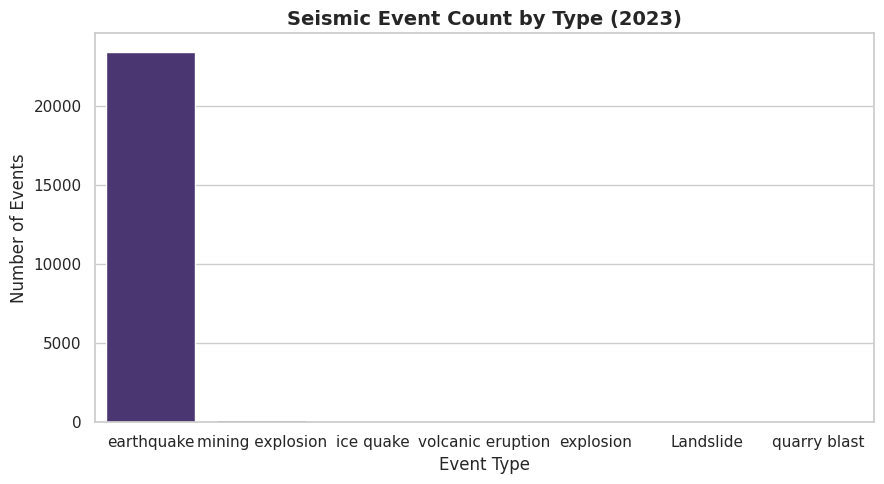

In [0]:
# ── Plot 1: Event Type Distribution ────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=event_summary, x='event_type', y='total_events',
            palette='viridis', ax=ax)
ax.set_title('Seismic Event Count by Type (2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Event Type')
ax.set_ylabel('Number of Events')
plt.tight_layout()
plt.show()

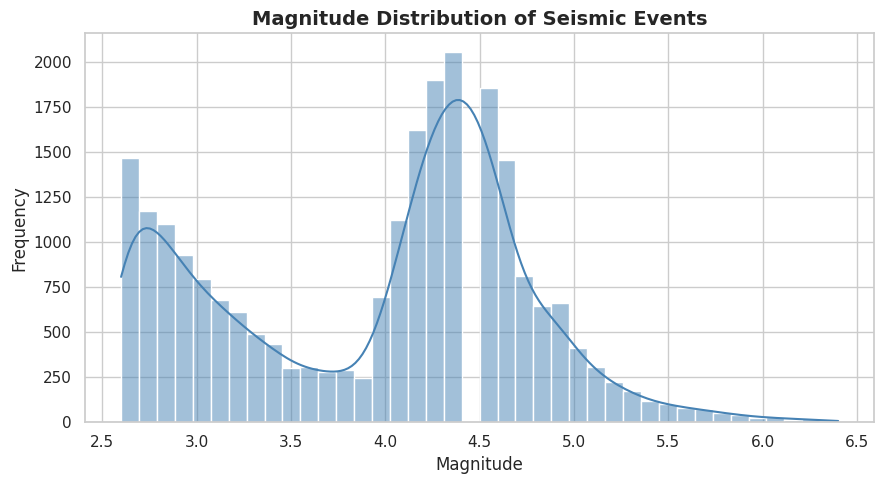

In [0]:
# ── Plot 2: Magnitude Distribution ─────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df['mag'], bins=40, kde=True, color='steelblue', ax=ax)
ax.set_title('Magnitude Distribution of Seismic Events', fontsize=14, fontweight='bold')
ax.set_xlabel('Magnitude')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

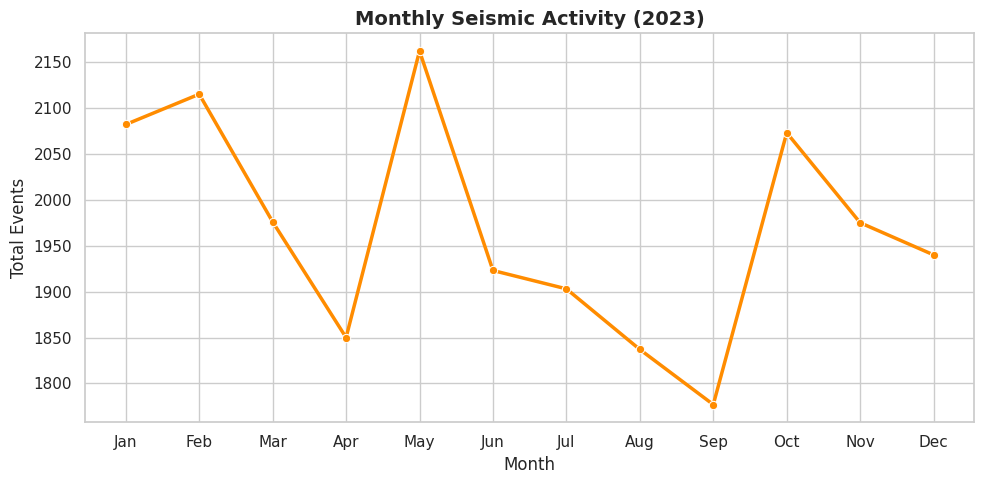

In [0]:
# ── Plot 3: Monthly Seismic Activity ───────────────────────────
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=monthly, x='month', y='total_events',
             marker='o', color='darkorange', linewidth=2.5, ax=ax)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_title('Monthly Seismic Activity (2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Events')
plt.tight_layout()
plt.show()

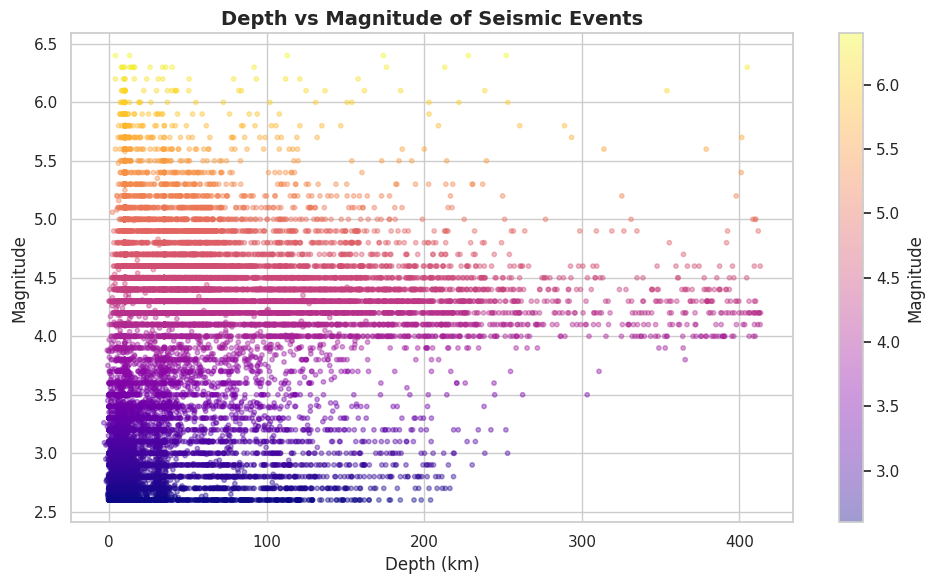

In [0]:
# ── Plot 4: Depth vs Magnitude Scatter ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(df['depth'], df['mag'],
                c=df['mag'], cmap='plasma', alpha=0.4, s=10)
plt.colorbar(sc, ax=ax, label='Magnitude')
ax.set_title('Depth vs Magnitude of Seismic Events', fontsize=14, fontweight='bold')
ax.set_xlabel('Depth (km)')
ax.set_ylabel('Magnitude')
plt.tight_layout()
plt.show()

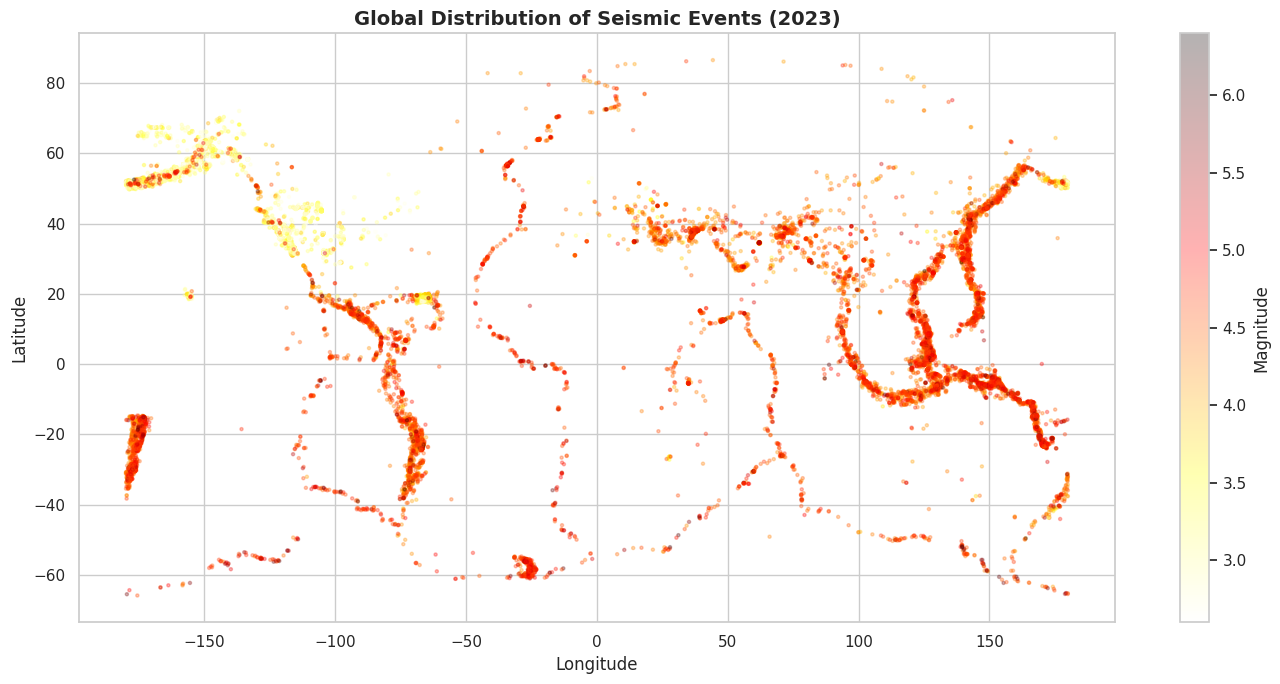

In [0]:
# ── Plot 5: Global Geographic Distribution ─────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
sc = ax.scatter(df['longitude'], df['latitude'],
                c=df['mag'], cmap='hot_r', alpha=0.3, s=5)
plt.colorbar(sc, ax=ax, label='Magnitude')
ax.set_title('Global Distribution of Seismic Events (2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

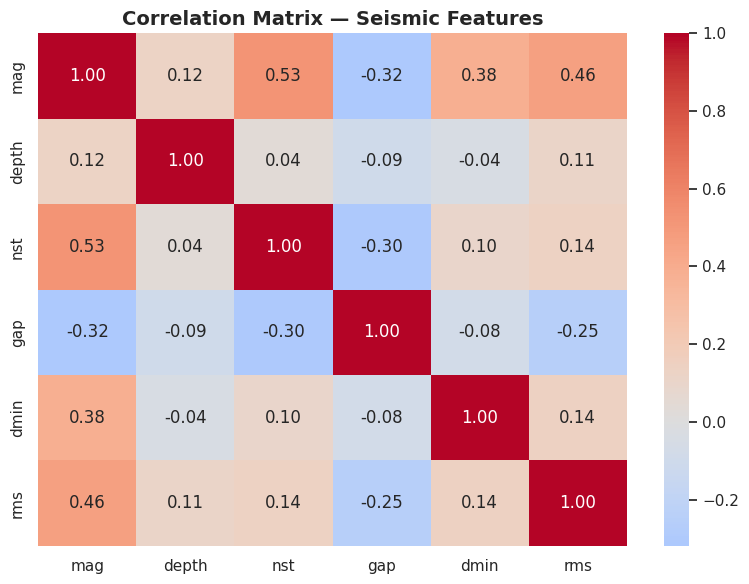

In [0]:
# ── Plot 6: Correlation Heatmap ────────────────────────────
corr_cols = [c for c in ['mag','depth','nst','gap','dmin','rms'] if c in df.columns]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix — Seismic Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 7 — K-Means Clustering (scikit-learn)

Grouping seismic events by **latitude, longitude, magnitude, and depth** to identify distinct behavioral and geographic clusters.

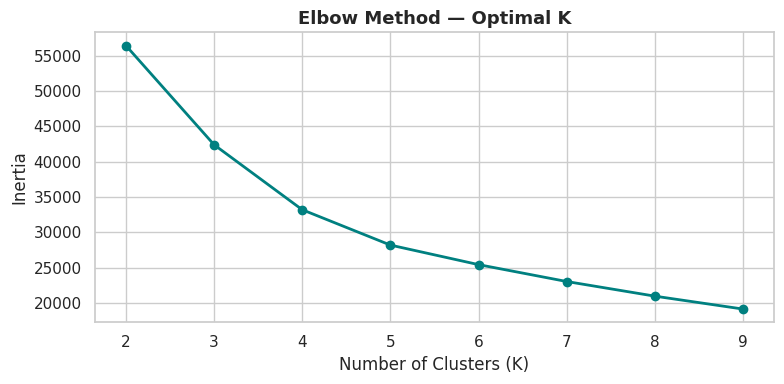

In [0]:
# Feature selection & standardisation
cluster_features = [c for c in ['latitude','longitude','mag','depth'] if c in df.columns]
X_cluster = df[cluster_features].dropna()

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Elbow method
inertia = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(2, 10), inertia, marker='o', color='teal', linewidth=2)
ax.set_title('Elbow Method — Optimal K', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia')
plt.tight_layout()
plt.show()

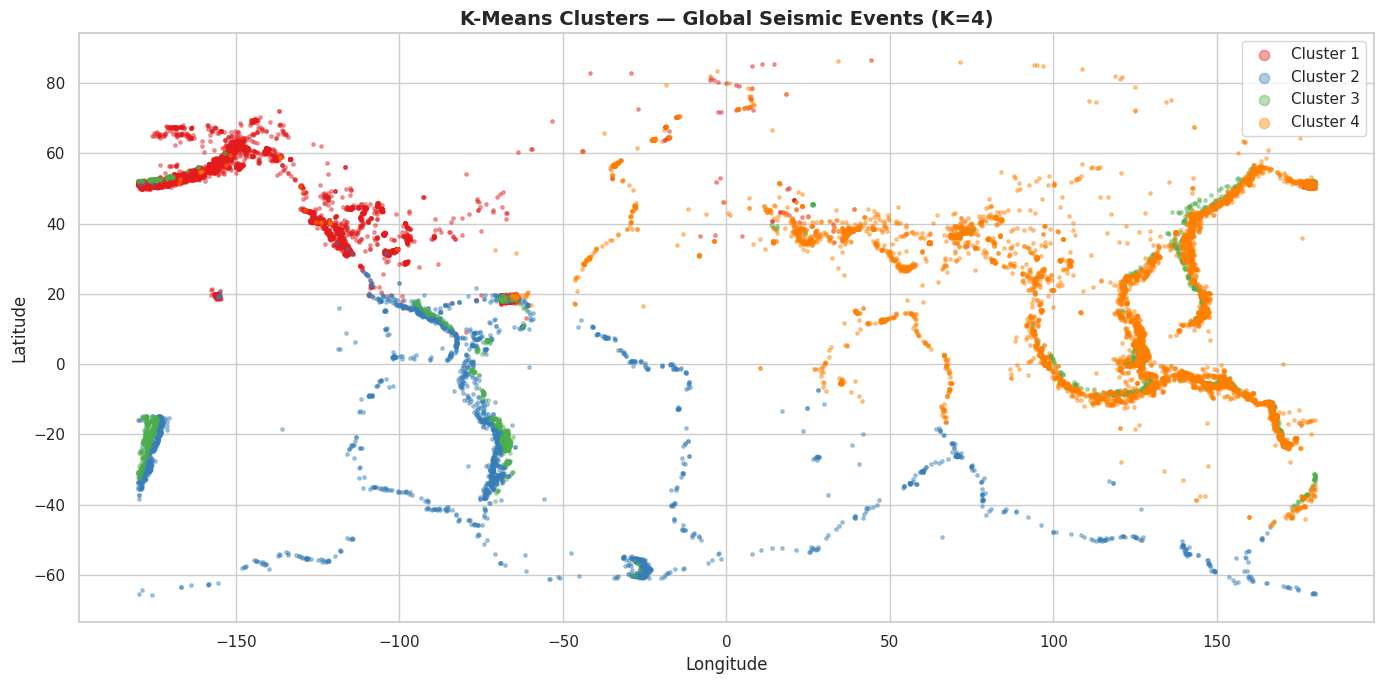


Cluster Centroids (mean values):


latitude,longitude,mag,depth
42.13,-125.02,3.08,29.14
-21.98,-84.29,4.58,34.52
1.69,36.74,4.31,195.04
16.55,114.12,4.49,30.67


In [0]:
# Fit K=4 (consistent with R analysis)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster = X_cluster.copy()
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

# Geographic cluster plot
colors = ['#e41a1c','#377eb8','#4daf4a','#ff7f00']
fig, ax = plt.subplots(figsize=(14, 7))
for i in range(4):
    s = df_cluster[df_cluster['cluster'] == i]
    ax.scatter(s['longitude'], s['latitude'],
               c=colors[i], s=6, alpha=0.4, label=f'Cluster {i+1}')
ax.set_title('K-Means Clusters — Global Seismic Events (K=4)', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

# Cluster summary table
print('\nCluster Centroids (mean values):')
display(df_cluster.groupby('cluster')[cluster_features].mean().round(2))

## Section 8 — Event Type Classification (Random Forest)

Predicting seismic event type from spatial and measurement features using a **Random Forest classifier** with a 70/30 train-test split.

In [0]:
model_features = [c for c in ['latitude','longitude','mag','depth','nst','gap','dmin','rms']
                  if c in df.columns]

df_model = df[model_features + ['type']].dropna()
df_model = df_model[df_model['type'] != 'Unknown'].copy()

le = LabelEncoder()
df_model['type_encoded'] = le.fit_transform(df_model['type'])

X = df_model[model_features]
y = df_model['type_encoded']

# 70 / 30 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'Random Forest Accuracy : {acc*100:.2f}%')
print('\nClassification Report:')

# Get unique labels present in y_test
unique_labels = sorted(y_test.unique())
label_names = [le.classes_[i] for i in unique_labels]

print(classification_report(y_test, y_pred, labels=unique_labels, target_names=label_names))

Random Forest Accuracy : 99.93%

Classification Report:
                   precision    recall  f1-score   support

        Landslide       0.00      0.00      0.00         1
       earthquake       1.00      1.00      1.00      7021
        explosion       0.00      0.00      0.00         1
        ice quake       0.89      1.00      0.94         8
 mining explosion       1.00      1.00      1.00        50
volcanic eruption       0.00      0.00      0.00         3

         accuracy                           1.00      7084
        macro avg       0.48      0.50      0.49      7084
     weighted avg       1.00      1.00      1.00      7084



/databricks/python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/databricks/python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/databricks/python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


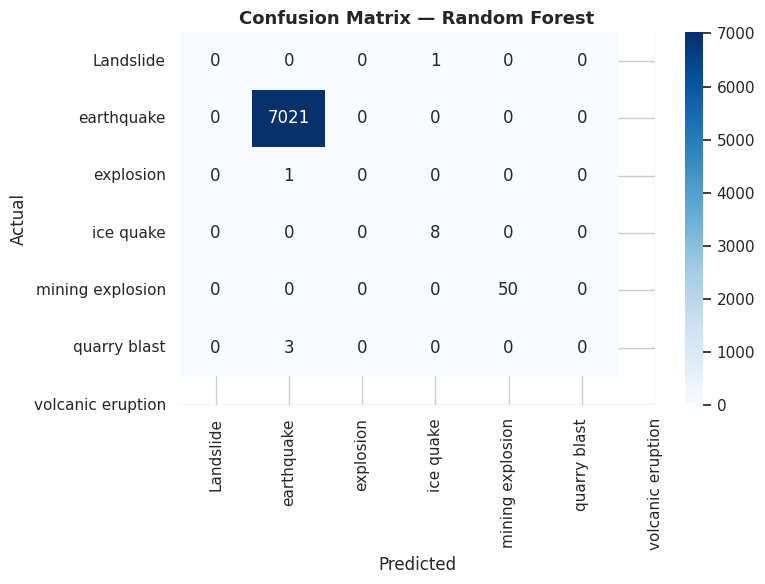

In [0]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

/home/spark-c07e526f-8e98-499b-b276-ec/.ipykernel/2129/command-5218907317430919-3706292976:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='magma', ax=ax)


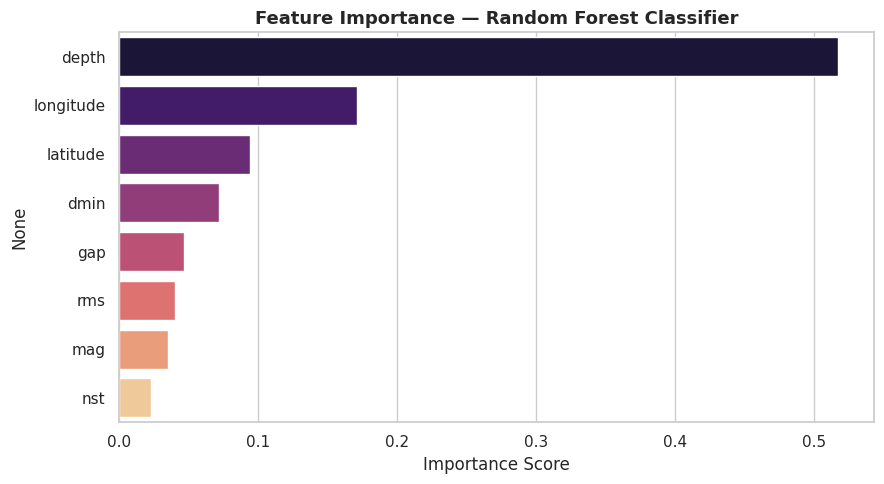


Ranked Feature Importance:


Feature,Importance
depth,0.5174226332900371
longitude,0.1710514907698107
latitude,0.09405382580999454
dmin,0.07180740215555327
gap,0.046659606107603
rms,0.040449118189581884
mag,0.035471854992634715
nst,0.023084068684784863


In [0]:
# Feature Importance
importances = pd.Series(rf.feature_importances_, index=model_features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=importances.values, y=importances.index, palette='magma', ax=ax)
ax.set_title('Feature Importance — Random Forest Classifier', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nRanked Feature Importance:')
display(importances.reset_index().rename(columns={'index':'Feature', 0:'Importance'}))